# Project 1 :  Demand Forecasting
## Part 1 of 3 : Data  Preparation



**Dataset:** [M5 Forecasting – Accuracy (Walmart / Kaggle)](https://www.kaggle.com/competitions/m5-forecasting-accuracy). 42,840 hierarchical daily time series of unit sales across 3 US states (CA, TX, WI), 10 stores, 3 categories, and 3,049 products, spanning 2011-01-29 -> 2016-06-19.

---
### Why this project matters?
Demand forecasting is the heartbeat of supply chain planning. Every downstream decision like how much inventory to hold, how to position it across fulfillment centers, when to reorder depends on a forecast. The cost of being wrong is asymmetric:

- Over-forecast -> overstock -> holding cost, markdowns, wasted working capital, spoilage.
- Under-forecast -> stockouts -> lost sales, poor customer experience, lost trust.

Retail demand is also hard: it is intermittent (many products sell 0 units most days), highly seasonal, promotion-driven, and price-sensitive. This notebook builds the clean, leakage-free data foundation that the rest of the project depends on.

### What Part 1 delivers
1. Load and profile the four raw tables (calendar, prices, sales, submission template).
2. Memory optimization via dtype downcasting (the raw sales table is ~120 MB / 30,490 rows × 1,941 day-columns).
3. Reshape the wide sales matrix into a tidy long (tabular) panel and align frequencies by joining the calendar + price tables.
4. Handle missing values and distinguish true zeros from not-yet-listed / out-of-stock periods.
5. Outlier detection tuned for volatile, intermittent retail demand.
6. Persist a clean modeling table (Parquet) for Parts 2 and 3.

### Configuration
The full panel is 30,490 series × 1,941 days ~ 59M rows. The new pipeline is identical at any scale, so we run the cheap, full-data aggregate analyses on the wide matrix directly, and build the expensive long-format modeling table for one store (`CA_1`, all 3,049 products). 

In [1]:
import os, warnings, gc
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)

DATA_DIR = "."                 # raw M5 CSVs live alongside the notebooks
STORE_ID = "CA_1"              # store used for the long-format modeling table
PROCESSED_PATH = "processed_store_CA_1.parquet"

print("pandas", pd.__version__, "| numpy", np.__version__)

pandas 3.0.3 | numpy 2.4.6


## 1. Load & profile the raw tables

We inspect shape, dtypes, missing data, and memory of each file before touching it. *Profiling first* prevents silent dtype/missing-value bugs later.

In [2]:
calendar = pd.read_csv(os.path.join(DATA_DIR, "calendar.csv"))
prices   = pd.read_csv(os.path.join(DATA_DIR, "sell_prices.csv"))
sales    = pd.read_csv(os.path.join(DATA_DIR, "sales_train_evaluation.csv"))  # d_1..d_1941
submission = pd.read_csv(os.path.join(DATA_DIR, "sample_submission.csv"))

def profile(df, name):
    print(f"\n=== {name} ===")
    print("shape:", df.shape, "| memory: %.1f MB" % (df.memory_usage(deep=True).sum()/1e6))
    miss = df.isna().mean().sort_values(ascending=False)
    miss = miss[miss > 0]
    print("columns with missing values:", dict(miss.round(3)) if len(miss) else "none")

for d, n in [(calendar,"calendar"), (prices,"sell_prices"), (sales,"sales"), (submission,"submission")]:
    profile(d, n)


=== calendar ===
shape: (1969, 14) | memory: 0.3 MB
columns with missing values: {'event_type_2': np.float64(0.997), 'event_name_2': np.float64(0.997), 'event_name_1': np.float64(0.918), 'event_type_1': np.float64(0.918)}

=== sell_prices ===
shape: (6841121, 4) | memory: 333.6 MB
columns with missing values: none

=== sales ===
shape: (30490, 1947) | memory: 476.8 MB


columns with missing values: none

=== submission ===
shape: (60980, 29) | memory: 15.9 MB
columns with missing values: none


In [3]:
# Peek at the calendar — the table that maps day-ids (d_1..) to real dates, events and SNAP flags
calendar.head()

,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,2011-01-29,11101,Saturday,1,1,2011,d_1,NaN,NaN,NaN,NaN,0,0,0
1,2011-01-30,11101,Sunday,2,1,2011,d_2,NaN,NaN,NaN,NaN,0,0,0
2,2011-01-31,11101,Monday,3,1,2011,d_3,NaN,NaN,NaN,NaN,0,0,0
3,2011-02-01,11101,Tuesday,4,2,2011,d_4,NaN,NaN,NaN,NaN,1,1,0
4,2011-02-02,11101,Wednesday,5,2,2011,d_5,NaN,NaN,NaN,NaN,1,0,1


**Reading the calendar.** Each row is one day. Key columns:
- `d` : the day-id (`d_1` … `d_1941`) that the sales matrix uses as column headers.
- `wm_yr_wk` : Walmart retail week id; the *join key to the price table* (prices change weekly, not daily).
- `event_name_1/2`, `event_type_1/2` — calendar events (holidays, sporting, religious, cultural). Up to two per day. These are exogenous demand drivers.
- `snap_CA / snap_TX / snap_WI` : binary flags marking days when SNAP (US food-assistance) benefits can be spent in each state. SNAP days reliably lift food demand and are the backbone of the causal study in Project 2.

The missingness in `event_name_*` is **structural, not dirty data**: most days simply have no event. We will encode "no event" explicitly rather than treating it as missing.

In [4]:
# The sales matrix is WIDE: one row per series, one column per day (d_1..d_1941)
print("id columns:", [c for c in sales.columns if not c.startswith('d_')])
print("n day columns:", sum(c.startswith('d_') for c in sales.columns))
sales.iloc[:5, :11]

id columns: ['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id']
n day columns: 1941


,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,d_5
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,0
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,0
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,0
3,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,0
4,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,0


In [5]:
# Hierarchy profiling — the dimensions a supply chain team plans across
id_cols = ["id","item_id","dept_id","cat_id","store_id","state_id"]
print("series:", len(sales))
for c in ["state_id","store_id","cat_id","dept_id"]:
    print(f"\n{c} ({sales[c].nunique()} unique):")
    print(sales[c].value_counts().to_string())
print("\nunique products (item_id):", sales.item_id.nunique())

series: 30490

state_id (3 unique):
state_id
CA    12196
TX     9147
WI     9147

store_id (10 unique):
store_id
CA_1    3049
CA_2    3049
CA_3    3049
CA_4    3049
TX_1    3049
TX_2    3049
TX_3    3049
WI_1    3049
WI_2    3049
WI_3    3049

cat_id (3 unique):
cat_id
FOODS        14370
HOUSEHOLD    10470
HOBBIES       5650

dept_id (7 unique):
dept_id
FOODS_3        8230
HOUSEHOLD_1    5320
HOUSEHOLD_2    5150
HOBBIES_1      4160
FOODS_2        3980
FOODS_1        2160
HOBBIES_2      1490

unique products (item_id): 3049


The series nest: `state -> store -> category -> department -> item`. FOODS_3 alone is 8,230 series and is the largest and most volatile slice. A real forecast must be *coherent* across this hierarchy (store forecasts should sum to state forecasts). We profile it now so every later choice (sampling, weighting, the wRMSSE metric) respects this structure.

## 2. Memory optimization (dtype downcasting)

The sales counts fit in `int16`; ids are low-cardinality strings best stored as `category`. Downcasting shrinks memory and speeds up every subsequent groupby/merge.

In [6]:
def reduce_mem(df):
    before = df.memory_usage(deep=True).sum()/1e6
    for c in df.columns:
        t = df[c].dtype
        if pd.api.types.is_integer_dtype(t):
            df[c] = pd.to_numeric(df[c], downcast="integer")
        elif pd.api.types.is_float_dtype(t):
            df[c] = pd.to_numeric(df[c], downcast="float")
        elif t == object:
            if df[c].nunique() / max(len(df), 1) < 0.5:
                df[c] = df[c].astype("category")
    after = df.memory_usage(deep=True).sum()/1e6
    print(f"  {before:7.1f} MB -> {after:7.1f} MB  ({100*(1-after/before):.0f}% smaller)")
    return df

print("calendar:");  calendar = reduce_mem(calendar)
print("prices:");    prices   = reduce_mem(prices)
print("sales:");     sales    = reduce_mem(sales)

calendar:
      0.3 MB ->     0.2 MB  (34% smaller)
prices:


    333.6 MB ->   265.2 MB  (21% smaller)
sales:


    476.8 MB ->   102.2 MB  (79% smaller)


## 3.  Full-data aggregate EDA (on the wide matrix)

Total sales over time, by category and by state, are just column sums of the wide matrix this is instant even on all 30,490 series. This gives the macro picture before we narrow to one store.

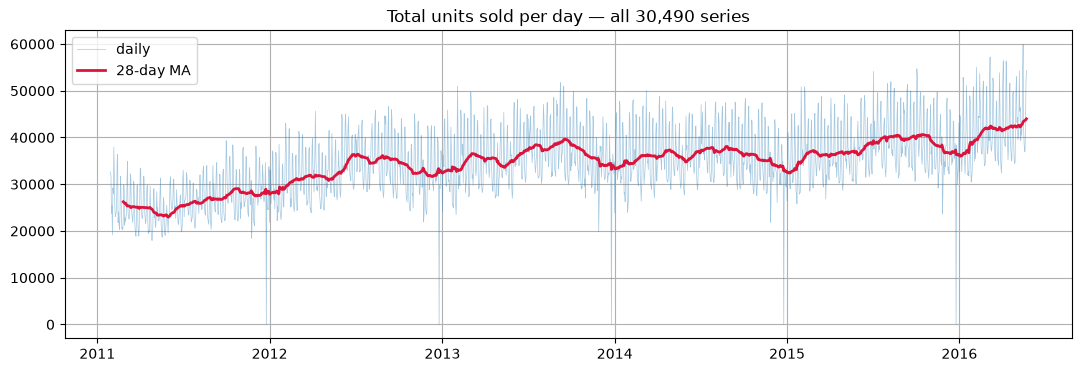

In [7]:
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (13, 4)
plt.rcParams["axes.grid"] = True

day_cols = [c for c in sales.columns if c.startswith("d_")]
cal_idx = calendar.set_index("d")["date"]                 # d_x -> date
dates = pd.to_datetime(cal_idx.reindex(day_cols).values)

total = pd.Series(sales[day_cols].sum(axis=0).values, index=dates)
total_30 = total.rolling(28).mean()
plt.plot(total.index, total.values, lw=0.5, alpha=0.4, label="daily")
plt.plot(total_30.index, total_30.values, color="crimson", lw=2, label="28-day MA")
plt.title("Total units sold per day — all 30,490 series"); plt.legend(); plt.show()

**What the aggregate shows:** A clear upward trend (Walmart growing), strong weekly seasonality, an annual cycle, and sharp near-zero dips on Christmas (stores closed) this is the most important recurring outlier in this dataset. The trend means raw levels are non-stationary, which we test formally in Part 2 and which motivates differencing / detrending for classical models.

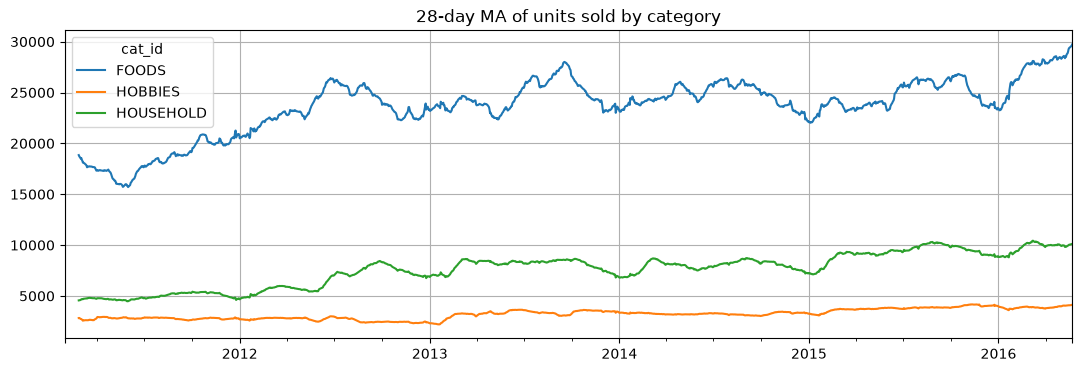

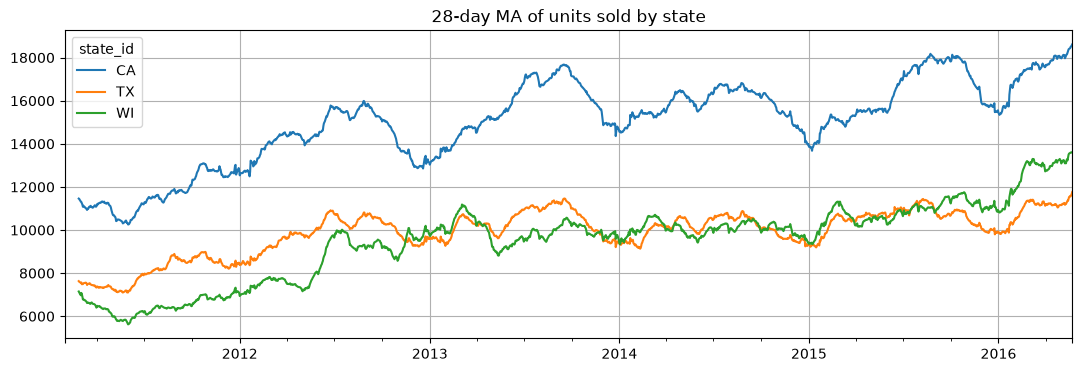

In [8]:
cat_daily = sales.groupby("cat_id", observed=True)[day_cols].sum().T
cat_daily.index = dates
cat_daily.rolling(28).mean().plot(title="28-day MA of units sold by category")
plt.show()

state_daily = sales.groupby("state_id", observed=True)[day_cols].sum().T
state_daily.index = dates
state_daily.rolling(28).mean().plot(title="28-day MA of units sold by state")
plt.show()

FOODS dominates volume and is the most seasonal; HOBBIES is small and spiky. CA has the highest volume (4 stores vs 3). These differences mean a *single global model* is rarely optimal so, we will engineer category/state features so the model can learn segment-specific behavior.

## 4. Reshape to long panel 
Classical and ML forecasters expect a long panel: one row per (series, day). We melt the wide matrix for the configured store, then join the calendar (daily keys) and prices (weekly keys) 

In [9]:
sales_sub = sales[sales["store_id"] == STORE_ID].copy()
print(f"{STORE_ID}: {len(sales_sub)} series x {len(day_cols)} days")

long = sales_sub.melt(id_vars=id_cols, value_vars=day_cols, var_name="d", value_name="sales")
long = reduce_mem(long)
print("melted long panel:", long.shape)

# Align to daily calendar (date, week-id, events, SNAP)
cal_keep = ["d","date","wm_yr_wk","wday","month","year",
            "event_name_1","event_type_1","event_name_2","event_type_2",
            "snap_CA","snap_TX","snap_WI"]
long = long.merge(calendar[cal_keep], on="d", how="left")
long["date"] = pd.to_datetime(long["date"])

# Align weekly prices onto daily rows via (store, item, week)
long = long.merge(prices, on=["store_id","item_id","wm_yr_wk"], how="left")
long = long.sort_values(["id","date"]).reset_index(drop=True)
print("after joins:", long.shape)
long.head()

CA_1: 3049 series x 1941 days


    753.3 MB ->   753.3 MB  (0% smaller)
melted long panel: (5918109, 8)


after joins: (5918109, 21)


,id,item_id,dept_id,cat_id,store_id,state_id,d,sales,date,wm_yr_wk,wday,month,year,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI,sell_price
0,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_1,3,2011-01-29,11101,1,1,2011,NaN,NaN,NaN,NaN,0,0,0,2.0
1,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_2,0,2011-01-30,11101,2,1,2011,NaN,NaN,NaN,NaN,0,0,0,2.0
2,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_3,0,2011-01-31,11101,3,1,2011,NaN,NaN,NaN,NaN,0,0,0,2.0
3,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_4,1,2011-02-01,11101,4,2,2011,NaN,NaN,NaN,NaN,1,1,0,2.0
4,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_5,4,2011-02-02,11101,5,2,2011,NaN,NaN,NaN,NaN,1,0,1,2.0


## 5. Missing values: true zeros vs. not-yet-listed / out-of-stock

This is the single most important data-quality decision in M5. A `0` in the sales matrix can mean two very different things, and conflating them poisons a forecast.

In [10]:
# sell_price is missing exactly when an item was NOT actively sold in that week.
print("rows with missing sell_price: %.1f%%" % (100*long["sell_price"].isna().mean()))

# Define the ACTIVE window per series: from its first real sale onward.
first_sale = (long[long["sales"] > 0].groupby("id", observed=True)["date"].min()
              .rename("first_sale_date"))
long = long.merge(first_sale, on="id", how="left")
long["pre_launch"] = long["date"] < long["first_sale_date"]      # not yet listed
long["price_avail"] = long["sell_price"].notna()                 # offered for sale that week

print("pre-launch (drop): %.1f%%" % (100*long["pre_launch"].mean()))
print("active rows kept :", (~long["pre_launch"]).sum())

rows with missing sell_price: 19.1%


pre-launch (drop): 19.2%
active rows kept : 4781564


**Decision & justification:**
- Pre-launch zeros (before a product's first ever sale) are structural absence of demand, not low demand. Feeding them to a model teaches it a fake "this product sells nothing" pattern and biases forecasts downward at launch. We drop them.
- Active-period zeros are kept so they are genuine demand signal (intermittent / slow-moving items legitimately sell 0 on many days). Throwing them away would bias forecasts upward and inflate safety stock.
- Missing `sell_price` inside the active window flags a likely out-of-stock / not-offered week. We keep the row but mark it with `price_avail`, so a model can learn that zero-sales-while-unavailable ≠ zero-demand.

In [11]:
long = long[~long["pre_launch"]].copy()

# Encode "no event" explicitly rather than as missing
for c in ["event_name_1","event_type_1","event_name_2","event_type_2"]:
    long[c] = long[c].astype("object").fillna("none").astype("category")

# State-specific SNAP flag for this store's state (CA_1 -> snap_CA)
state = sales_sub["state_id"].iloc[0]
long["snap"] = long[f"snap_{state}"].astype("int8")

# Forward-fill price within the active window (price is sticky week to week)
long["sell_price"] = long.groupby("id", observed=True)["sell_price"].ffill()
long["sell_price"] = long.groupby("id", observed=True)["sell_price"].bfill()
print("remaining missing sell_price: %d" % long["sell_price"].isna().sum())
print("active-period zero-sales share: %.1f%%" % (100*(long["sales"]==0).mean()))

remaining missing sell_price: 0
active-period zero-sales share: 55.1%


## 6. Outlier detection 

A naive global z-score is wrong here: most series are intermittent, so the mean/SD are dominated by zeros and every sale looks like an outlier. We instead use a per-series rolling-median absolute deviation (Hampel-style) filter on the active window, which is robust to zeros and to legitimate seasonal spikes.

flagged points: 0.328% of active rows


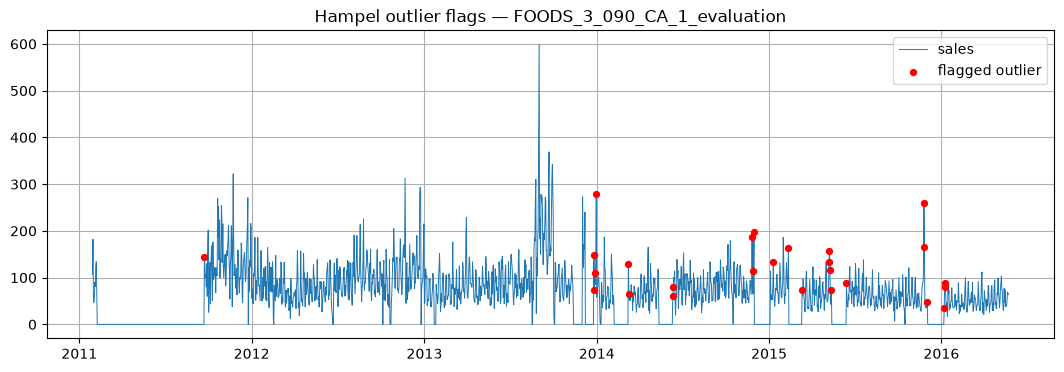

In [12]:
def hampel_flags(s, window=28, n_sigma=6):
    med = s.rolling(window, center=True, min_periods=7).median()
    mad = (s - med).abs().rolling(window, center=True, min_periods=7).median()
    sigma = 1.4826 * mad                      # MAD -> std for normal data
    upper = med + n_sigma * sigma
    return (s > upper) & (sigma > 0)          # only flag implausible HIGH spikes

# Apply per series; demo on the highest-volume item in the store
g = long.groupby("id", observed=True)["sales"]
long["is_outlier"] = g.transform(lambda s: hampel_flags(s.reset_index(drop=True)).values)
print("flagged points: %.3f%% of active rows" % (100*long["is_outlier"].mean()))

top_item = long.groupby("id", observed=True)["sales"].sum().idxmax()
ex = long[long["id"] == top_item]
plt.plot(ex["date"], ex["sales"], lw=0.7, label="sales")
plt.scatter(ex.loc[ex["is_outlier"],"date"], ex.loc[ex["is_outlier"],"sales"],
            color="red", s=18, zorder=5, label="flagged outlier")
plt.title(f"Hampel outlier flags — {top_item}"); plt.legend(); plt.show()

**Why flag, not delete.** In retail, a "spike" is often a *real* promotional surge ans is exactly the demand we most need to predict. So we **flag** rather than remove. Downstream we can (a) keep the flag as a feature, (b) winsorize (cap) only the most extreme points for classical models that are sensitive to them, or (c) leave them in for tree models, which are robust. We keep the raw value plus the flag and let each model decide. We use `n_sigma=6` to be conservative and  we want to catch data-entry errors, not normal promo volatility.

## 7. Persist the clean modeling table

We save a compact Parquet that Parts 2 and 3 load directly, keeping each notebook fast and self-contained.

In [13]:
keep = ["id","item_id","dept_id","cat_id","store_id","state_id","date",
        "wm_yr_wk","wday","month","year","sales","sell_price","price_avail",
        "event_name_1","event_type_1","event_name_2","event_type_2",
        "snap","is_outlier"]
out = long[keep].copy()
out.to_parquet(PROCESSED_PATH, index=False)
print("saved", PROCESSED_PATH, "| rows:", len(out),
      "| %.1f MB" % (os.path.getsize(PROCESSED_PATH)/1e6))
out.head()

saved processed_store_CA_1.parquet | rows: 4781564 | 11.8 MB


,id,item_id,dept_id,cat_id,store_id,state_id,date,wm_yr_wk,wday,month,year,sales,sell_price,price_avail,event_name_1,event_type_1,event_name_2,event_type_2,snap,is_outlier
0,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,2011-01-29,11101,1,1,2011,3,2.0,True,none,none,none,none,0,False
1,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,2011-01-30,11101,2,1,2011,0,2.0,True,none,none,none,none,0,False
2,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,2011-01-31,11101,3,1,2011,0,2.0,True,none,none,none,none,0,False
3,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,2011-02-01,11101,4,2,2011,1,2.0,True,none,none,none,none,1,False
4,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,2011-02-02,11101,5,2,2011,4,2.0,True,none,none,none,none,1,False


---
## Part 1 summary & what's next
 Profiled and memory-optimized the raw M5 tables; established the product hierarchy; reshaped the `CA_1` store into a tidy daily panel; aligned daily calendar/event/SNAP and weekly price data; separated structural pre-launch zeros from genuine intermittent zeros; flagged out-of-stock weeks; and applied a robust Hampel outlier filter suited to spiky retail demand.


**Part 2 ( EDA & Time-Series Analysis):** quantify intermittency, measure promotion, holiday, SNAP and price effects, run STL decomposition and ADF/KPSS stationarity tests, read ACF/PACF,  lag/rolling features, and apply PCA to the exogenous calendar matrix.